# ⚠️ Notebook 4: Risk Scoring + AI Agent Logic
### SupplyChain-AI-Agent | AIML Lab Assignment

**Input:** `Datasets/predictions.csv`  
**Output:** `Datasets/final_output.csv`

**What we do here:**
- Convert model probabilities into Low / Medium / High risk levels
- Apply a rule-based agent to generate a recommendation for each order
- Test the agent on sample orders
- Validate that risk levels align with actual outcomes

---

## 0. Imports & Setup

In [25]:
import pandas as pd           # for loading CSV data and manipulating the predictions DataFrame
import numpy as np            # for numerical operations
import matplotlib.pyplot as plt  # for plotting risk distribution charts
import seaborn as sns         # for nicer chart aesthetics
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1. Load Predictions

In [26]:
# Load the predictions CSV produced by Notebook 3
# This file contains every order with its delay_probability and predicted_late columns
df = pd.read_csv('../Datasets/predictions.csv')

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')   # show all column names

# Summarise the three key columns from the model output:
#   delay_probability: how likely each order is to be late (0.0 → 1.0)
#   predicted_late: model's binary prediction (0 = on time, 1 = late)
#   Late_delivery_risk: actual ground truth (0 = on time, 1 = actually late)
df[['delay_probability','predicted_late','Late_delivery_risk']].describe().round(3)

Loaded: 180,519 rows × 31 columns

Columns: ['Order Id', 'Days for shipment (scheduled)', 'scheduled_days_bin', 'order_month', 'order_dayofweek', 'order_quarter', 'is_weekend_order', 'Sales', 'Order Profit Per Order', 'Order Item Quantity', 'Order Item Discount Rate', 'profit_margin_ratio', 'revenue_per_item', 'high_discount_flag', 'high_value_order', 'shipping_mode_risk', 'market_risk_score', 'category_late_rate', 'dept_late_rate', 'segment_late_rate', 'ship_mode_x_sched', 'shipping_mode_enc', 'market_enc', 'customer_segment_enc', 'department_name_enc', 'category_name_enc', 'order_status_enc', 'Late_delivery_risk', 'predicted_late', 'delay_probability', 'prediction_correct']


,delay_probability,predicted_late,Late_delivery_risk
count,180519.000,180519.000,180519.000
mean,0.516,0.346,0.548
std,0.262,0.476,0.498
min,0.015,0.000,0.000
25%,0.342,0.000,0.000
50%,0.366,0.000,1.000
75%,0.760,1.000,1.000
max,0.999,1.000,1.000


---
## 2. Risk Scoring
### 2.1 Define Risk Levels

In [27]:
# ── Risk thresholds ───────────────────────────────────────────────────────
# These boundaries divide the continuous probability (0–1) into three risk buckets
# LOW:    probability < 0.30  → low chance of delay, no urgent action needed
# MEDIUM: 0.30 ≤ probability < 0.70 → moderate risk, needs monitoring
# HIGH:   probability ≥ 0.70  → high chance of delay, immediate action required
LOW_THRESHOLD  = 0.30
HIGH_THRESHOLD = 0.70

def assign_risk_level(prob):
    """Convert a delay probability (0–1) into a risk label (LOW/MEDIUM/HIGH)."""
    if prob < LOW_THRESHOLD:
        return 'LOW'      # probability is small — order likely to be on time
    elif prob < HIGH_THRESHOLD:
        return 'MEDIUM'   # probability is moderate — uncertain, needs review
    else:
        return 'HIGH'     # probability is large — action needed immediately

# Apply the function to every row's delay_probability to create the risk_level column
# .apply() calls assign_risk_level once for each value in the column
df['risk_level'] = df['delay_probability'].apply(assign_risk_level)

# Print how many orders fall into each risk category
print('Risk level distribution:')
risk_counts = df['risk_level'].value_counts()
for level, count in risk_counts.items():
    pct = count / len(df) * 100    # compute percentage of total orders
    print(f'  {level:<8}: {count:>7,}  ({pct:.1f}%)')

Risk level distribution:
  MEDIUM  : 112,477  (62.3%)
  HIGH    :  58,877  (32.6%)
  LOW     :   9,165  (5.1%)


### 2.2 Visualise Risk Distribution

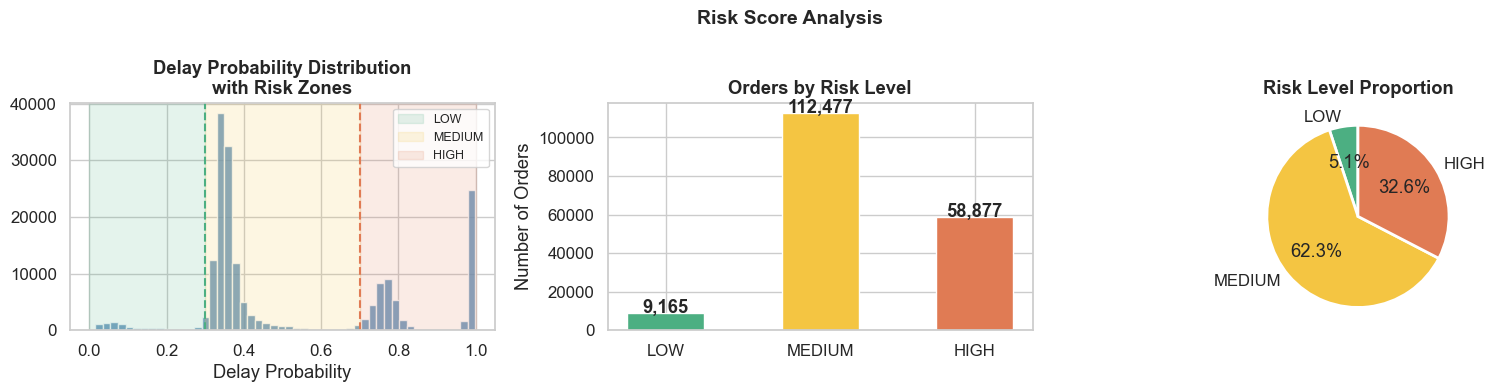

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Chart 1: probability histogram with coloured risk zones ──────────────
axes[0].hist(df['delay_probability'], bins=50, color='#5B8DB8',
             edgecolor='white', alpha=0.8)
# axvspan adds a coloured background band between two x-values
# This visually marks which part of the probability axis is LOW / MEDIUM / HIGH risk
axes[0].axvspan(0, LOW_THRESHOLD,              alpha=0.15, color='#4CAF82', label='LOW')
axes[0].axvspan(LOW_THRESHOLD, HIGH_THRESHOLD, alpha=0.15, color='#F4C542', label='MEDIUM')
axes[0].axvspan(HIGH_THRESHOLD, 1,             alpha=0.15, color='#E07B54', label='HIGH')
# Vertical dashed lines mark the exact threshold boundaries
axes[0].axvline(LOW_THRESHOLD,  color='#4CAF82', linestyle='--', linewidth=1.5)
axes[0].axvline(HIGH_THRESHOLD, color='#E07B54', linestyle='--', linewidth=1.5)
axes[0].set_title('Delay Probability Distribution\nwith Risk Zones', fontweight='bold')
axes[0].set_xlabel('Delay Probability')
axes[0].legend(fontsize=9)

# ── Chart 2: count of orders in each risk level ───────────────────────────
order  = ['LOW', 'MEDIUM', 'HIGH']
colors = ['#4CAF82', '#F4C542', '#E07B54']   # green/yellow/orange = LOW/MEDIUM/HIGH
vals   = [risk_counts.get(r, 0) for r in order]
axes[1].bar(order, vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Orders by Risk Level', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
# Annotate each bar with the exact count
for i, v in enumerate(vals):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# ── Chart 3: pie chart showing proportions ────────────────────────────────
# autopct='%1.1f%%' adds percentage labels inside each pie slice
# startangle=90 rotates chart so the first slice starts at the top
axes[2].pie(vals, labels=order, colors=colors, autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[2].set_title('Risk Level Proportion', fontweight='bold')

plt.suptitle('Risk Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Agent Rule Engine

In [29]:
def generate_recommendation(row):
    """
    Rule-based AI agent: takes a single order row and returns a
    human-readable recommendation string based on risk level + order features.

    Priority order (most urgent first):
      HIGH risk + severe delay       → Escalate to Express Shipping
      HIGH risk + negative profit    → Consider Cancellation or Re-route
      HIGH risk (general)            → Switch to Faster Shipping Mode
      MEDIUM risk + high value order → Assign Priority Tracking
      MEDIUM risk + high discount    → Verify Supplier Commitment
      MEDIUM risk (general)          → Flag for Supervisor Review
      LOW risk                       → No Action Required
    """
    # Extract the features we need for decision-making from this order row
    risk     = row['risk_level']                          # LOW, MEDIUM, or HIGH
    delay    = row.get('delay_severity', row.get('delay_gap', 0))  # how many days late
    profit   = row.get('Order Profit Per Order', 0)       # profit — negative means a loss
    discount = row.get('high_discount_flag', 0)           # 1 if discount > 10%
    value    = row.get('high_value_order', 0)             # 1 if order is high value
    prob     = row['delay_probability']                   # raw predicted probability

    # ── HIGH RISK branch ──────────────────────────────────────────────────
    if risk == 'HIGH':
        if delay >= 3:
            # Very severe delay (3+ days late) on a high-risk order → escalate immediately
            return '🚨 Escalate: Switch to Express Shipping immediately'
        elif profit < 0:
            # High risk AND losing money on this order → cancellation may be better
            return '🔴 High Risk + Loss Order: Consider Cancellation or Re-route'
        else:
            # High risk, general case → upgrade shipping mode to prevent delay
            return '🔴 High Delay Risk: Switch to Faster Shipping Mode'

    # ── MEDIUM RISK branch ───────────────────────────────────────────────
    elif risk == 'MEDIUM':
        if value == 1 and prob >= 0.55:
            # High-value order with moderate-to-high risk → give it priority tracking
            return '🟡 High-Value Order at Risk: Assign Priority Tracking'
        elif discount == 1:
            # Discounted orders sometimes have weaker supplier commitments
            return '🟡 Discounted Order with Moderate Risk: Verify Supplier Commitment'
        else:
            # General medium-risk → flag for a human supervisor to review
            return '🟡 Moderate Delay Risk: Flag for Supervisor Review'

    # ── LOW RISK branch ──────────────────────────────────────────────────
    else:
        # Probability is low — no intervention needed, proceed as normal
        return '🟢 Low Risk: No Action Required — Proceed as Normal'


# Apply the agent function to EVERY row in the DataFrame
# axis=1 tells apply() to pass each row (not each column) into the function
df['recommendation'] = df.apply(generate_recommendation, axis=1)

print('Recommendation distribution:')
print(df['recommendation'].value_counts().to_string())   # .to_string() avoids truncation

Recommendation distribution:
recommendation
🟡 Moderate Delay Risk: Flag for Supervisor Review                    55801
🟡 Discounted Order with Moderate Risk: Verify Supplier Commitment    55761
🔴 High Delay Risk: Switch to Faster Shipping Mode                    48213
🔴 High Risk + Loss Order: Consider Cancellation or Re-route          10664
🟢 Low Risk: No Action Required — Proceed as Normal                    9165
🟡 High-Value Order at Risk: Assign Priority Tracking                   915


## 4. Test the Agent

In [30]:
def agent_report(order_row):
    """Print a formatted single-order decision report so we can verify the agent output."""
    print('=' * 60)
    oid = order_row.get('Order Id', 'N/A')   # retrieve Order Id if column exists
    print(f'  ORDER ID  : {oid}')
    print(f'  Delay Prob: {order_row["delay_probability"]:.2%}')   # format as percentage
    print(f'  Risk Level: {order_row["risk_level"]}')
    print(f'  Actual Late: {"Yes" if order_row["Late_delivery_risk"] == 1 else "No"}')
    print('-' * 60)
    print(f'  💡 RECOMMENDATION:')
    print(f'     {order_row["recommendation"]}')
    print('=' * 60)

# Test the agent on one sample order from each risk bucket
print('--- SAMPLE: High Risk Order ---')
high_sample = df[df['risk_level'] == 'HIGH'].iloc[0]   # first HIGH risk order
agent_report(high_sample)

print('\n--- SAMPLE: Medium Risk Order ---')
med_sample = df[df['risk_level'] == 'MEDIUM'].iloc[0]  # first MEDIUM risk order
agent_report(med_sample)

print('\n--- SAMPLE: Low Risk Order ---')
low_sample = df[df['risk_level'] == 'LOW'].iloc[0]     # first LOW risk order
agent_report(low_sample)

--- SAMPLE: High Risk Order ---
  ORDER ID  : 75934
  Delay Prob: 99.26%
  Risk Level: HIGH
  Actual Late: Yes
------------------------------------------------------------
  💡 RECOMMENDATION:
     🔴 High Delay Risk: Switch to Faster Shipping Mode

--- SAMPLE: Medium Risk Order ---
  ORDER ID  : 77202
  Delay Prob: 37.19%
  Risk Level: MEDIUM
  Actual Late: No
------------------------------------------------------------
  💡 RECOMMENDATION:
     🟡 Moderate Delay Risk: Flag for Supervisor Review

--- SAMPLE: Low Risk Order ---
  ORDER ID  : 75935
  Delay Prob: 7.38%
  Risk Level: LOW
  Actual Late: No
------------------------------------------------------------
  💡 RECOMMENDATION:
     🟢 Low Risk: No Action Required — Proceed as Normal


In [31]:
# Test the agent on any specific Order ID
# Change the index value below to test different orders interactively

if 'Order Id' in df.columns:
    test_id = df['Order Id'].iloc[100]   # use order at row index 100
    order = df[df['Order Id'] == test_id].iloc[0]  # retrieve that order by its ID
    print(f'Testing agent on Order ID: {test_id}')
    agent_report(order)
else:
    # Fallback: use row index directly if Order Id column is not present
    print('Testing agent on row index 100:')
    agent_report(df.iloc[100])

Testing agent on Order ID: 52478
  ORDER ID  : 52478
  Delay Prob: 32.98%
  Risk Level: MEDIUM
  Actual Late: No
------------------------------------------------------------
  💡 RECOMMENDATION:
     🟡 Discounted Order with Moderate Risk: Verify Supplier Commitment


## 5. Validate Agent vs Actual Outcomes

In [32]:
# Measure how well each risk bucket aligns with actual late deliveries
# This tells us whether the risk levels are calibrated correctly:
#   HIGH risk bucket should have the highest actual late rate
#   LOW risk bucket should have the lowest actual late rate

risk_accuracy = df.groupby('risk_level').agg(
    total_orders  = ('Late_delivery_risk', 'count'),   # total orders per bucket
    actual_late   = ('Late_delivery_risk', 'sum'),     # how many were actually late
    avg_delay_prob= ('delay_probability', 'mean')      # average probability per bucket
)

# Compute the actual late percentage for each risk bucket
risk_accuracy['actual_late_pct'] = (
    risk_accuracy['actual_late'] / risk_accuracy['total_orders'] * 100
).round(2)

# Reorder rows so LOW / MEDIUM / HIGH appear in logical ascending order
risk_accuracy = risk_accuracy.loc[['LOW','MEDIUM','HIGH']]
print('Agent Risk Level vs Actual Outcomes:')
print(risk_accuracy.to_string())

Agent Risk Level vs Actual Outcomes:
            total_orders  actual_late  avg_delay_prob  actual_late_pct
risk_level                                                            
LOW                 9165           53        0.126477             0.58
MEDIUM            112477        45547        0.364221            40.49
HIGH               58877        53377        0.866256            90.66


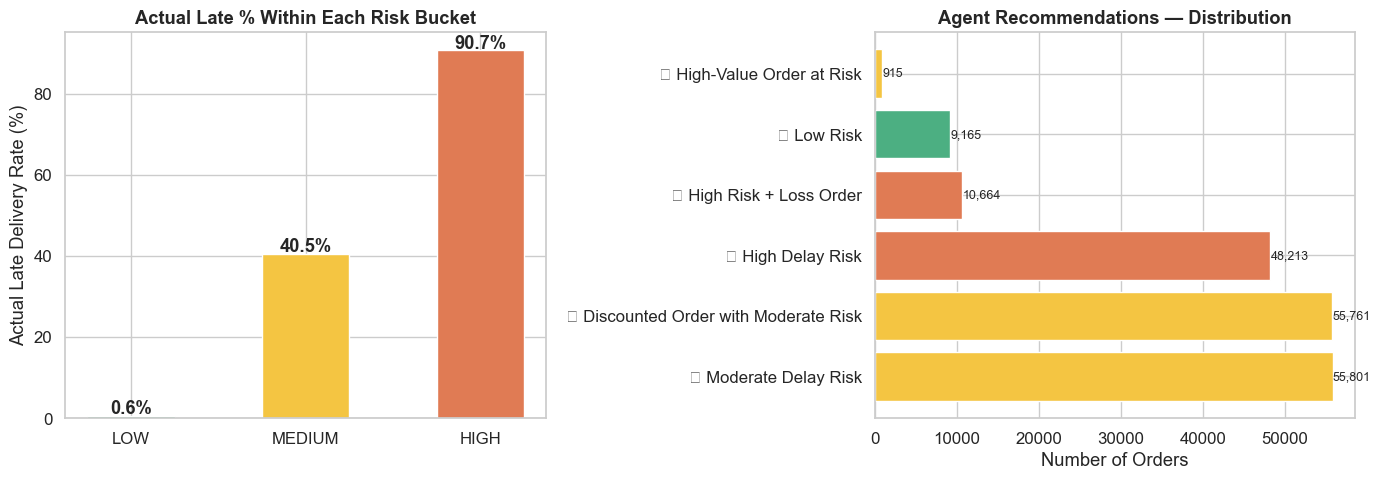

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: actual late % within each risk bucket ────────────────────────
# If the agent works well: LOW bucket → low late %, HIGH bucket → high late %
order_levels = ['LOW', 'MEDIUM', 'HIGH']
colors       = ['#4CAF82', '#F4C542', '#E07B54']   # green/yellow/orange
late_pcts    = risk_accuracy.loc[order_levels, 'actual_late_pct'].values

axes[0].bar(order_levels, late_pcts, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Actual Late % Within Each Risk Bucket', fontweight='bold')
axes[0].set_ylabel('Actual Late Delivery Rate (%)')
# Add percentage labels on top of each bar
for i, v in enumerate(late_pcts):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 2: recommendation type breakdown ────────────────────────────────
# Shows how many orders received each type of recommendation from the agent
rec_counts = df['recommendation'].value_counts()

# Shorten labels to the text before the colon for readability
short_labels = [r.split(':')[0] for r in rec_counts.index]

# Colour-code bars based on urgency emoji in the recommendation string
rec_colors = ['#E07B54' if '🚨' in r or '🔴' in r
              else '#F4C542' if '🟡' in r else '#4CAF82'
              for r in rec_counts.index]

axes[1].barh(short_labels, rec_counts.values, color=rec_colors)
axes[1].set_title('Agent Recommendations — Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
# Label each bar with its exact count
for i, v in enumerate(rec_counts.values):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Save Final Output

In [34]:
# Define which columns to include in the final output file
# We keep human-readable columns (not encoded integers) so the output is interpretable
output_cols = [
    'Order Id',                    # unique identifier — links prediction back to the original order
    'Sales',                       # total order value in USD
    'Order Profit Per Order',      # profit — useful context for cancellation decisions
    'Order Item Quantity',         # number of items in the order
    'Days for shipment (scheduled)',  # what shipping time was promised
    'Days for shipping (real)',    # actual time taken (from predictions file)
    'delay_gap',                   # actual − scheduled (positive = late)
    'delay_severity',              # how many days late (0 if on time)
    'Late_delivery_risk',          # ground truth: was the order actually late?
    'delay_probability',           # model's predicted probability of being late
    'predicted_late',              # model's binary prediction (0 or 1)
    'risk_level',                  # agent's risk label (LOW / MEDIUM / HIGH)
    'recommendation',              # agent's action recommendation
]

# Only include columns that actually exist (guards against missing cols from predictions.csv)
output_cols = [c for c in output_cols if c in df.columns]

# Create the final output DataFrame with selected columns
final_df = df[output_cols].copy()

# Save to CSV — this is the main output file consumed by Notebook 5 and stakeholders
final_df.to_csv('../Datasets/final_output.csv', index=False)

print(f'✅ final_output.csv saved → {final_df.shape[0]:,} rows × {final_df.shape[1]} cols')
print('\nSample output:')
# Display 5 random rows showing the three most important output columns
final_df[['delay_probability','risk_level','recommendation']].sample(5)

✅ final_output.csv saved → 180,519 rows × 10 cols

Sample output:


,delay_probability,risk_level,recommendation
42028,0.9900,HIGH,🔴 High Delay Risk: Switch to Faster Shipping Mode
140828,0.3707,MEDIUM,🟡 Moderate Delay Risk: Flag for Supervisor Review
102358,0.3428,MEDIUM,🟡 Discounted Order with Moderate Risk: Verify ...
93094,0.3477,MEDIUM,🟡 Discounted Order with Moderate Risk: Verify ...
102009,0.3470,MEDIUM,🟡 Moderate Delay Risk: Flag for Supervisor Review


In [35]:
# Print a final summary of what the agent processed and recommended
print('=' * 60)
print('  AGENT SUMMARY')
print('=' * 60)
print(f'  Total orders processed : {len(final_df):,}')

# Count orders in each risk bucket using boolean comparison
# (final_df['risk_level']=='HIGH') returns a boolean Series; .sum() counts the Trues
print(f'  HIGH risk orders       : {(final_df["risk_level"]=="HIGH").sum():,}')
print(f'  MEDIUM risk orders     : {(final_df["risk_level"]=="MEDIUM").sum():,}')
print(f'  LOW risk orders        : {(final_df["risk_level"]=="LOW").sum():,}')
print('-' * 60)

# All orders that are not LOW risk need some form of action
print(f'  Orders needing action  : {(final_df["risk_level"]!="LOW").sum():,}')
print('=' * 60)
print('\n→ Next step: Run Notebook 5 — Visualization & Analysis')

  AGENT SUMMARY
  Total orders processed : 180,519
  HIGH risk orders       : 58,877
  MEDIUM risk orders     : 112,477
  LOW risk orders        : 9,165
------------------------------------------------------------
  Orders needing action  : 171,354

→ Next step: Run Notebook 5 — Visualization & Analysis
